In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("fifa_eda.csv")

In [18]:
df.head(5)

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0


In [19]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  object 
 7   Value                     17955 non-null  float64
 8   Wage                      18207 non-null  float64
 9   Preferred Foot            18207 non-null  object 
 10  International Reputation  18159 non-null  float64
 11  Skill Moves               18159 non-null  float64
 12  Position                  18207 non-null  object 
 13  Joined                    18207 non-null  int64  
 14  Contra

In [20]:
df.isnull().sum()

ID                            0
Name                          0
Age                           0
Nationality                   0
Overall                       0
Potential                     0
Club                        241
Value                       252
Wage                          0
Preferred Foot                0
International Reputation     48
Skill Moves                  48
Position                      0
Joined                        0
Contract Valid Until        289
Height                        0
Weight                        0
Release Clause                0
dtype: int64

In [21]:
df=df.dropna(subset=['Club','Contract Valid Until','International Reputation','Skill Moves','Value'])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17907 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        17907 non-null  int64  
 1   Name                      17907 non-null  object 
 2   Age                       17907 non-null  int64  
 3   Nationality               17907 non-null  object 
 4   Overall                   17907 non-null  int64  
 5   Potential                 17907 non-null  int64  
 6   Club                      17907 non-null  object 
 7   Value                     17907 non-null  float64
 8   Wage                      17907 non-null  float64
 9   Preferred Foot            17907 non-null  object 
 10  International Reputation  17907 non-null  float64
 11  Skill Moves               17907 non-null  float64
 12  Position                  17907 non-null  object 
 13  Joined                    17907 non-null  int64  
 14  Contract Va

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


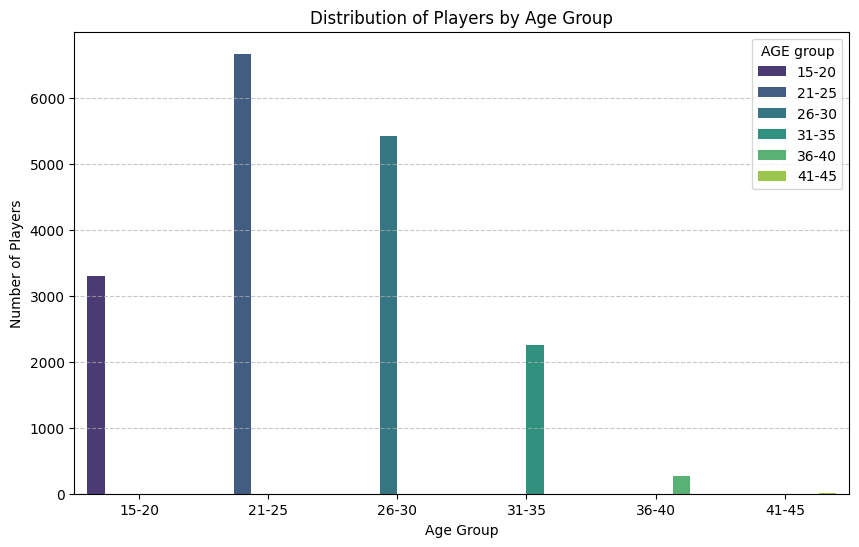

In [23]:
# Define age bins and labels
bins = [15, 20, 25, 30, 35, 40, 45]
labels = ['15-20', '21-25', '26-30', '31-35', '36-40', '41-45']

# Create 'AGE group' column
df['AGE group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Count players in each age group
age_group_counts = df['AGE group'].value_counts().sort_index()

# Plotting the bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, hue=age_group_counts.index, palette='viridis')
plt.title('Distribution of Players by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Players')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


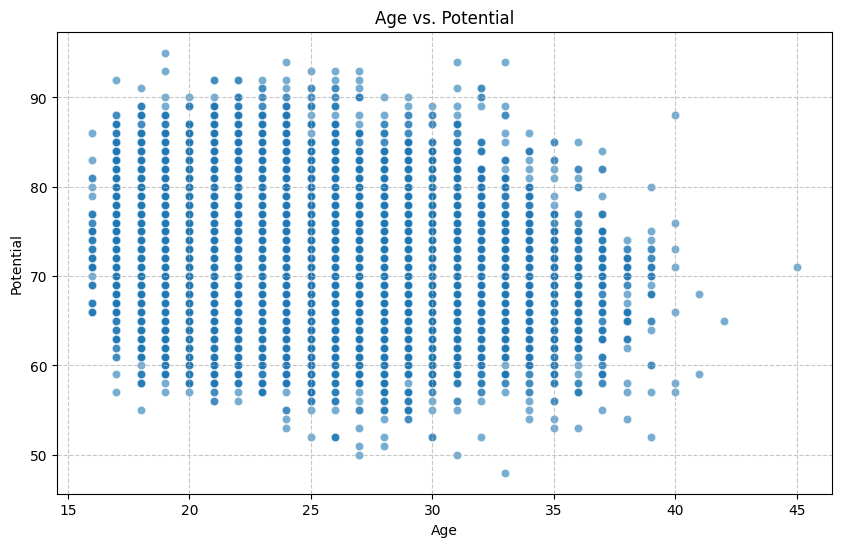

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Potential', data=df, alpha=0.6)
plt.title('Age vs. Potential')
plt.xlabel('Age')
plt.ylabel('Potential')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

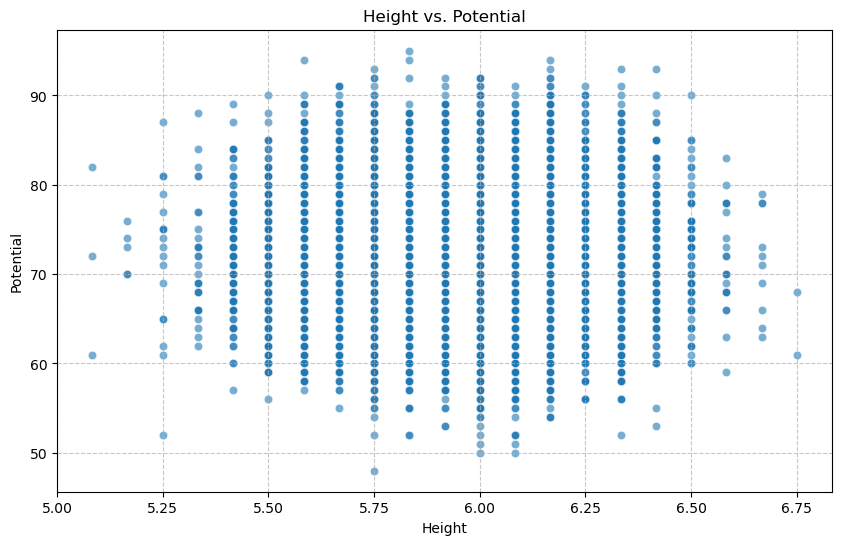

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Height', y='Potential', data=df, alpha=0.6)
plt.title('Height vs. Potential')
plt.xlabel('Height')
plt.ylabel('Potential')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

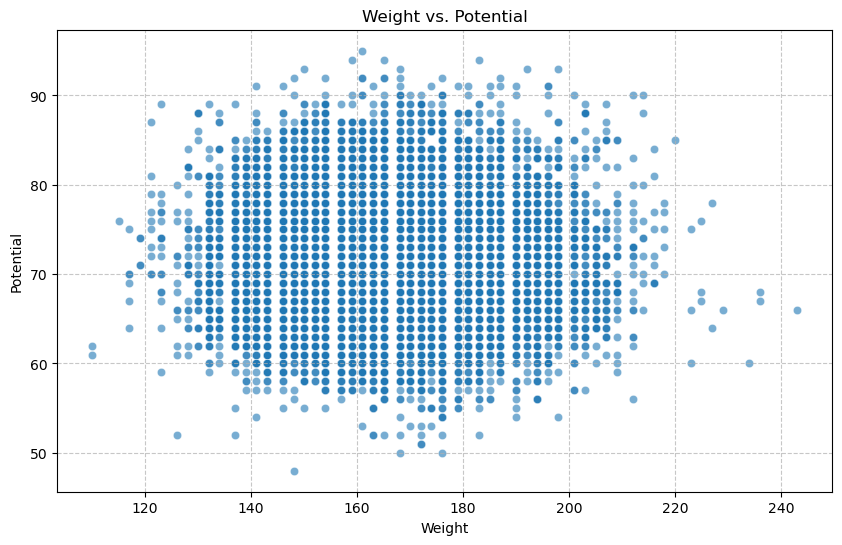

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Weight', y='Potential', data=df, alpha=0.6)
plt.title('Weight vs. Potential')
plt.xlabel('Weight')
plt.ylabel('Potential')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()